# Greenland Ice Velocity Hagen Bræ tutorial
The PROMICE Ice Velocity product is a time-series of Greenland Ice Sheet velocity mosaics based on ESA Sentinel-1 SAR offset tracking (spatial resolution: 200 m). A new mosaic spanning 2 Sentinel-1A/-1B/-1C cycles is posted every 12 days, with each new mosaic supplied as a NetCDF file. The data product is described in detail in [Solgaard et al. (2021)](https://doi.org/10.5194/essd-13-3491-2021). We aim to make each new mosaic available within 10 days of the last included acquisition.

Here, we will look at how to query and fetch the dataset from our [Thredds server](https://thredds.geus.dk/), which is where we store and operationally update the PROMICE Ice Velocity product. Specifically, we will use the example of Hagen Bræ in Northwest Greenland to look at:
1. Connecting to the PROMICE Ice Velocity dataset file series using OpenDAP
2. Constructing and computing a velocity time-series from a flowline

So first, let's import all the packages we will be using.

In [14]:
# For dataset loading and handling
import xarray as xr
import numpy as np

# For plotting
import matplotlib.pyplot as plt

# For filename fetching
from siphon.catalog import TDSCatalog
from datetime import datetime
import re

## 1. Connecting to the PROMICE Ice Velocity dataset file series using OpenDAP
The PROMICE Ice Velocity product is available on the [GEUS Thredds server](https://thredds.geus.dk/) as a series of individual files representing each time step. First let's connect and fetch all files into a readable dataset using OpenDAP querying.

In [16]:
# Construct xml catalog
catalog_url = "https://thredds.geus.dk/thredds/catalog/IVdata/rotr/catalog.xml"
cat = TDSCatalog(catalog_url)

# Find OpenDAP file urls
urls = []
for name, ds in cat.datasets.items():
    if "OPENDAP" in ds.access_urls:
        urls.append(ds.access_urls["OPENDAP"])
print(f"Found {len(urls)} files")

# Print the latest 10 file names
urls[-10:]

Found 308 files


['https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251031_20251124.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251112_20251206.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251124_20251218.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251206_20251230.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251218_20260111.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251230_20260123.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260111_20260204.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260123_20260216.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260204_20260228.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260216_20260312.nc']

We now have a list of all the OpenDAP querable file URLs. These files all share the same spatial grid and work along a time coordinate, therefore we can safely combine them using Python's xarray package.

For this tutorial, let's extract the date range from the file URLs and only load files from the summer melt season (May to September) in 2025.

In [19]:
# Define start and end date
start = datetime(2025, 5, 1)
end = datetime(2025, 9, 1)

# Define function for extracting date range from file url
def extract_date_range(url):
    # Match YYYYMMDD_YYYYMMDD
    m = re.search(r'(\d{8})_(\d{8})\.nc$', url)
    if m:
        start_str, end_str = m.groups()
        start = datetime.strptime(start_str, "%Y%m%d")
        end = datetime.strptime(end_str, "%Y%m%d")
        return start, end
    else:
        return None, None

filtered_urls = []
for url in urls:
    s, e = extract_date_range(url)
    if s is None:
        continue
    # Include file if it overlaps target range
    if e >= start and s <= end:
        filtered_urls.append(url)

print("Files to load:")
for u in filtered_urls:
    print(u.split('/')[-1])


Files to load:
IV_ROTR_V5_20250410_20250504.nc
IV_ROTR_V5_20250422_20250516.nc
IV_ROTR_V5_20250504_20250528.nc
IV_ROTR_V5_20250516_20250609.nc
IV_ROTR_V5_20250528_20250621.nc
IV_ROTR_V5_20250609_20250703.nc
IV_ROTR_V5_20250621_20250715.nc
IV_ROTR_V5_20250703_20250727.nc
IV_ROTR_V5_20250715_20250808.nc
IV_ROTR_V5_20250727_20250820.nc
IV_ROTR_V5_20250808_20250901.nc
IV_ROTR_V5_20250820_20250913.nc
IV_ROTR_V5_20250901_20250925.nc


Right, we now have a list of file URLs that we can combine and open with xarray. Let's open the dataset and subset it spatially to our region of interest at Hagen Bræ.

In [23]:
# Open dataset
ds = xr.open_mfdataset(
    filtered_urls,
    data_vars="all",
    combine="by_coords",
    chunks={"time": 1}
)

# Define region of interest
x1=215000
x2=270000
y1=-890000
y2=-930000

# Extract dataset only for region
region = ds.sel(
    x=slice(x1, x2),
    y=slice(y1, y2),
    time=slice(start, end)
)

region


<xarray.Dataset> Size: 17MB
Dimensions:                                  (time: 11, bnds: 2, y: 201, x: 276)
Coordinates:
  * time                                     (time) datetime64[ns] 88B 2025-0...
  * y                                        (y) float64 2kB -8.9e+05 ... -9....
  * x                                        (x) float64 2kB 2.15e+05 ... 2.7...
Dimensions without coordinates: bnds
Data variables:
    crs                                      (time) |S64 704B b'' b'' ... b''
    time_bnds                                (time, bnds) datetime64[ns] 176B dask.array<chunksize=(1, 2), meta=np.ndarray>
    land_ice_surface_easting_velocity        (time, y, x) float32 2MB dask.array<chunksize=(1, 201, 276), meta=np.ndarray>
    land_ice_surface_northing_velocity       (time, y, x) float32 2MB dask.array<chunksize=(1, 201, 276), meta=np.ndarray>
    land_ice_surface_vertical_velocity       (time, y, x) float32 2MB dask.array<chunksize=(1, 201, 276), meta=np.ndarray>
    land_ice_surface_velocity_magnitude      (time, y, x) float32 2MB dask.array<chunksize=(1, 201, 276), meta=np.ndarray>
    land_ice_surface_easting_velocity_std    (time, y, x) float32 2MB dask.array<chunksize=(1, 201, 276), meta=np.ndarray>
    land_ice_surface_northing_velocity_std   (time, y, x) float32 2MB dask.array<chunksize=(1, 201, 276), meta=np.ndarray>
    land_ice_surface_velocity_magnitude_std  (time, y, x) float32 2MB dask.array<chunksize=(1, 201, 276), meta=np.ndarray>
Attributes:
    Conventions:                     CF-1.5
    time_coverage_start:             2025-04-10
    time_coverage_end:               2025-05-04
    sensors_used:                    Sentinel-1A,Sentinel-1C
    institution:                     GEUS
    methods_used:                    Offset-tracking
    calibration_method:              None
    title:                           Greenland Ice Velocity from 2025-04-10 t...
    summary:                         Greenland Ice Velocity from Sentinel-1 o...
    product_version:                 1.0
    DODS.strlen:                     0
    DODS_EXTRA.Unlimited_Dimension:  time

Let's now visualise the dataset. If we want to produce the average horizontal ice velocity over our region then we can calculate the mean of all ice velocity values over the time dimension. If we want to limit our query to a specific time period then we can also provide a time slice.

In [ ]:
# Define time period
start = "2025-08-01"
end =  "2025-09-01"

# Extract horizontal velocity magnitude
velocity = region["land_ice_surface_velocity_magnitude"]

# Calculate mean for all values across the defined time period
average_velocity = velocity.sel(time=slice(start, end)).mean(dim="time")

# Plot horizontal velocity magnitude at Hagen Brae for first time step
plt.figure()
average_velocity.plot()
plt.title(f"Average ice velocity magnitude from {start} to {end}")
plt.show()

Let's also produce monthly averages for horizontal surface velocity magnitude as a series of plots. This will give us a great overview of the dataset.

In [24]:
# Group horizontal surface velocities by month and compute averages
monthly_velocity = velocity.groupby("time.month").mean(dim="time")

# Find max and min values to compute
# consist colour scale
vmin = float(monthly_velocity.min())
vmax = float(monthly_velocity.max())

# Plot all annual summer melt season velocities
plt.figure()
monthly_velocity.plot(
    col="month",
    col_wrap=3,
    vmin=vmin,
    vmax=vmax
)
plt.show()

KeyboardInterrupt: 

## 2. Constructing and computing a velocity time-series from a flowline

Now let's generate a time-series of velocities across a flowline.

This flowline should be a one-dimensional line that represents a glacier's primary path of ice flow. We will firstly make a hypothetical flowline ourselves over the catchment of Hagen Bræ in Northeast Greenland. Then we will generate a velocity time-series over this flowline, capturing the average, minimum and maximum velocity.

Firstly, let's define our flowline as a set of predefined points. Then we will generate evenly spaced points along our flowline, and compute the cumulative distance along this. We'll plot it onto the first velocity field in our dataset, to see how it looks.

Error:curl error: Stream error in the HTTP/2 framing layer
Error:curl error: Stream error in the HTTP/2 framing layer


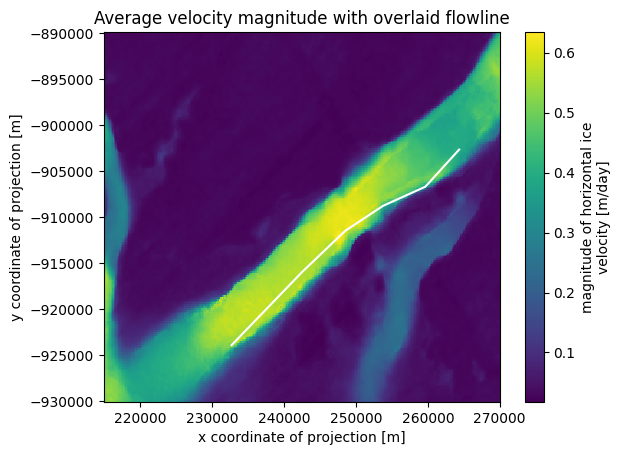

In [12]:
# Define flowline point locations
flowline_x = np.array([264352, 259672, 253754, 248511, 242556, 237624, 232692])
flowline_y = np.array([-902677, -906701, -908797, -911508, -915952, -919951, -923950])

dist_flowline = np.zeros(len(flowline_x))
for i in range(1, len(flowline_x)):
    dx = flowline_x[i] - flowline_x[i-1]
    dy = flowline_y[i] - flowline_y[i-1]
    dist_flowline[i] = dist_flowline[i-1] + np.sqrt(dx**2 + dy**2)

# Number of points along flowline
n_points = 100
even_dist = np.linspace(0, dist_flowline[-1], n_points)

# Interpolate x, y at evenly spaced distances
x_even = np.interp(even_dist, dist_flowline, flowline_x)
y_even = np.interp(even_dist, dist_flowline, flowline_y)

# Plot horizontal velocity magnitude at Hagen Brae
region = ds.sel(
    x=slice(x1, x2),
    y=slice(y1, y2)
)
plt.figure()
average_velocity.plot()
plt.title("Average velocity magnitude with overlaid flowline")

# Overlay flowline point locations
plt.plot(x_even, y_even, c="white")

# Show plot
plt.show()

We can now extract velocity values at the nearest grid points of the dataset using a nearest neighbour interpolation, carried out by the Dataset object.

In [13]:
flowline_vel = velocity.interp(
    x=("points", x_even),
    y=("points", y_even),
    method="nearest"
)
flowline_vel.shape

(308, 100)

In [14]:
flowline_mean = flowline_vel.mean(dim="points")
flowline_max = flowline_vel.max(dim="points")
flowline_min = flowline_vel.min(dim="points")

print(flowline_mean.values)
print(flowline_max.values)
print(flowline_min.values)

[0.6125893  0.599147   0.63920486 0.6098293  0.61021614 0.6283193
        nan        nan 0.6228931  0.63170147 0.6480967  0.647409
        nan        nan 0.8154698  0.68130887 0.41811278 0.4114486
 0.5035527  0.46425927 0.4744001  0.46570316 0.48435882 0.5016347
 0.47989908 0.4884159  0.48100907 0.49136162 0.48255065 0.4835311
 0.49155372 0.49062896 0.50438625 0.5047362  0.5115013  0.51170284
 0.51264954 0.516382   0.51907    0.5204955  0.5198871  0.53597844
 0.63937485 0.71491534 0.8564139  0.77846855 0.6462175  0.3978465
 0.4492891  0.45379454 0.45843187 0.46998453 0.48375905 0.47852883
 0.48314443 0.48623908 0.4918087  0.4990247  0.49794576 0.4893634
 0.49416503 0.5021263  0.5036646  0.5194194  0.52150124 0.521972
 0.5284857  0.5300654  0.53544    0.54832035 0.55236346 0.55246836
 0.55189496 0.56704265 0.6321673  0.716165   0.7394132  0.7882501
 0.6425184  0.6596275  0.67409617 0.685571   0.6908724  0.70126927
 0.698835   0.7182414  0.7057624  0.7000692  0.6784276  0.7041217
 0.7067

And then we can plot our velocity profile along the flowline, specifically plotting time versus flowline velocity (average, maximum and minimum).

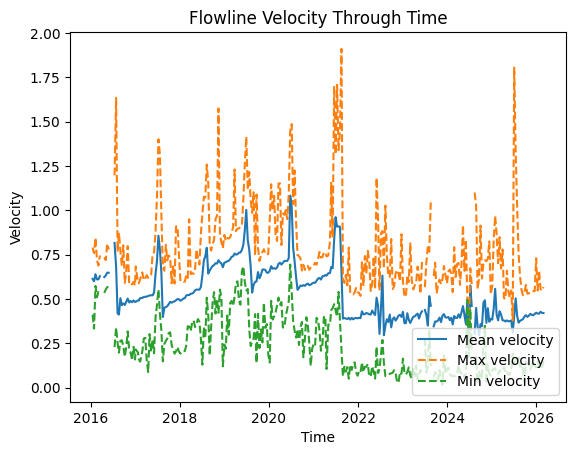

In [15]:
plt.figure()

plt.plot(flowline_vel.time, flowline_mean, label="Mean velocity")
plt.plot(flowline_vel.time, flowline_max, "--", label="Max velocity")
plt.plot(flowline_vel.time, flowline_min, "--", label="Min velocity")

plt.legend(loc="lower right")
plt.title("Flowline Velocity Through Time")
plt.xlabel("Time")
plt.ylabel("Velocity")

plt.show()